In [1]:
# ==========================================
#   IMPORT LIBRARIES & SETUP
# ==========================================

import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

## DATA LOADING

In [2]:
articles=pd.read_csv('data/articles.csv')
customers=pd.read_csv('data/customers.csv')


transactions=pd.read_csv(
    'data/transactions_train.csv',
    dtype={'article_id':'int32','price':'float32','sales_channel_id':'int8'},
    parse_dates=['t_dat']
)

## EDA: customers

In [3]:
customers.head()

,customer_id,FN,Active,club_member_status,fashion_news_frequency,age,postal_code
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,NaN,NaN,ACTIVE,NONE,49.0,52043ee2162cf5aa7ee79974281641c6f11a68d276429a...
1,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,NaN,NaN,ACTIVE,NONE,25.0,2973abc54daa8a5f8ccfe9362140c63247c5eee03f1d93...
2,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,NaN,NaN,ACTIVE,NONE,24.0,64f17e6a330a85798e4998f62d0930d14db8db1c054af6...
3,00005ca1c9ed5f5146b52ac8639a40ca9d57aeff4d1bd2...,NaN,NaN,ACTIVE,NONE,54.0,5d36574f52495e81f019b680c843c443bd343d5ca5b1c2...
4,00006413d8573cd20ed7128e53b7b13819fe5cfc2d801f...,1.0,1.0,ACTIVE,Regularly,52.0,25fa5ddee9aac01b35208d01736e57942317d756b32ddd...


In [4]:
print(customers.shape)
print('\n',customers.columns.tolist())
print('\n',customers.dtypes)

(1371980, 7)

 ['customer_id', 'FN', 'Active', 'club_member_status', 'fashion_news_frequency', 'age', 'postal_code']

 customer_id                object
FN                        float64
Active                    float64
club_member_status         object
fashion_news_frequency     object
age                       float64
postal_code                object
dtype: object


* postal_code: the postal code
* club_member_status: the customer's H&M club membership status
* fashion_news_frequency: how often the customer receives newsletters
* FN: indicates whether the customer receives "Fashion News" updates
* Active: indicates the customer's activity status (responsiveness to communications)

In [5]:
customers.isnull().sum()

customer_id                    0
FN                        895050
Active                    907576
club_member_status          6062
fashion_news_frequency     16011
age                        15861
postal_code                    0
dtype: int64

In [6]:
customers.describe()

,FN,Active,age
count,476930.0,464404.0,1.356119e+06
mean,1.0,1.0,3.638696e+01
std,0.0,0.0,1.431363e+01
min,1.0,1.0,1.600000e+01
25%,1.0,1.0,2.400000e+01
50%,1.0,1.0,3.200000e+01
75%,1.0,1.0,4.900000e+01
max,1.0,1.0,9.900000e+01


In [7]:
#Calculate the percentage of missing (NaN) values per column

percentage=customers.isna().mean()*100
percentage.round(2)

customer_id                0.00
FN                        65.24
Active                    66.15
club_member_status         0.44
fashion_news_frequency     1.17
age                        1.16
postal_code                0.00
dtype: float64

In [8]:
customers['FN'].value_counts(dropna=False)

FN
NaN    895050
1.0    476930
Name: count, dtype: int64

In [9]:
customers['fashion_news_frequency'].value_counts(dropna=False)

fashion_news_frequency
NONE         877711
Regularly    477416
NaN           16011
Monthly         842
Name: count, dtype: int64

In [10]:
pd.crosstab(customers['FN'],customers['fashion_news_frequency'],dropna=False)

fashion_news_frequency,Monthly,NONE,Regularly,NaN
FN,,,,
1.0,829,789,475310,2
NaN,13,876922,2106,16009


In [11]:
# Among customers with unknown FN, what share receives / does not receive / has unknown fashion news status

fn_off = customers['FN'].isna()
gets_news = customers['fashion_news_frequency'].isin(['Monthly', 'Regularly'])
no_news = customers['fashion_news_frequency'] == 'NONE'
no_info = customers['fashion_news_frequency'].isna()
number_off=fn_off.sum()

print("FN is unknown, customer receives news:", (fn_off & gets_news).sum()/number_off * 100)
print("FN is unknown, customer does not receive news:", (fn_off & no_news).sum()/number_off * 100)
print("FN is unknown, customer's news status is unknown:", (fn_off & no_info).sum()/number_off * 100)

FN is unknown, customer receives news: 0.23674655047204066
FN is unknown, customer does not receive news: 97.97463828836378
FN is unknown, customer's news status is unknown: 1.7886151611641805


* Replace missing values in FN with 0. Among customers with missing FN, ~98% receive no newsletters (NONE), ~0.24% do receive them, and ~1.8% also have an unknown newsletter status.

In [12]:
customers['Active'].value_counts(dropna=False)

Active
NaN    907576
1.0    464404
Name: count, dtype: int64

In [13]:
customers['club_member_status'].value_counts(dropna=False)

club_member_status
ACTIVE        1272491
PRE-CREATE      92960
NaN              6062
LEFT CLUB         467
Name: count, dtype: int64

In [14]:
pd.crosstab(customers['Active'],customers['club_member_status'],dropna=False)

club_member_status,ACTIVE,LEFT CLUB,PRE-CREATE,NaN
Active,,,,
1.0,458452,3,5631,318
NaN,814039,464,87329,5744


* Replace missing values in fashion_news_frequency with "Unknown"
* Replace missing values in club_member_status with "Unknown"
* Fill NaN values in Active with 0 as a placeholder

In [15]:
len(customers['age'].unique())
# 85 distinct ages

85

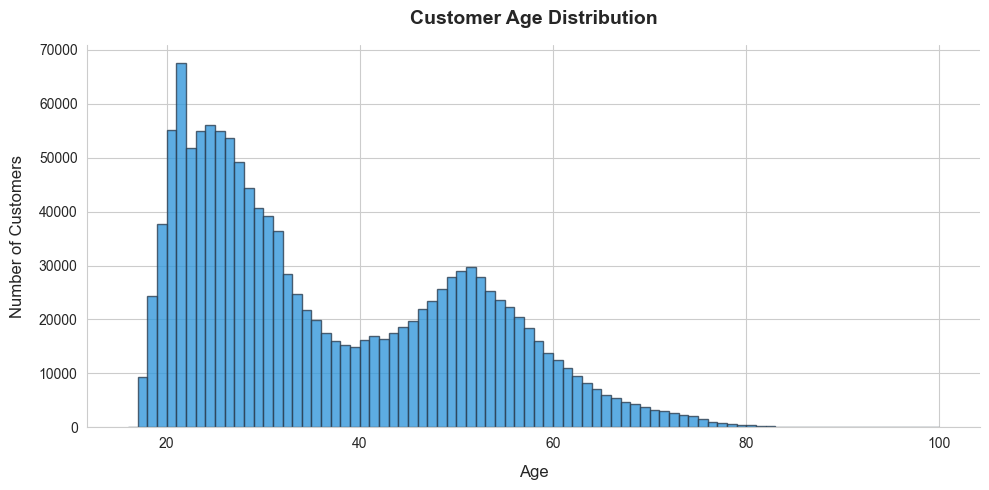

In [16]:
#Plot customer age distribution histogram
plt.figure(figsize=(10, 5))
sns.set_style("whitegrid")

age = customers['age'].dropna()

plt.hist(
    age, 
    bins=range(16,101), 
    color='#3498db',      
    edgecolor='#2c3e50',  
    alpha=0.8
)


plt.title('Customer Age Distribution', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Age', fontsize=12, labelpad=10)
plt.ylabel('Number of Customers', fontsize=12, labelpad=10)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

sns.despine()

plt.tight_layout()
plt.show()

In [17]:
customers['age'].value_counts().sort_values()

age
96.0        3
94.0        3
93.0        4
97.0        4
98.0        7
        ...  
23.0    54867
25.0    54989
20.0    55196
24.0    56124
21.0    67530
Name: count, Length: 84, dtype: int64

* Create a missing_age column
* Replace missing values in Age with the median

### Missing Values

In [18]:

customers['fashion_news_frequency'] = customers['fashion_news_frequency'].fillna('Unknown')

customers['club_member_status'] = customers['club_member_status'].fillna('Unknown')

customers['Active'] = customers['Active'].fillna(0).astype(int)
customers['FN'] = customers['FN'].fillna(0).astype(int)

customers['missing_age'] = customers['age'].isna().astype(int)
median_age = customers['age'].median()
customers['age'] = customers['age'].fillna(median_age)

* New Feature

In [19]:
customers['postal_code'].value_counts().head()

postal_code
2c29ae653a9282cce4151bd87643c907644e09541abc28ae87dea0d1f6603b1c    120303
cc4ed85e30f4977dae47662ddc468cd2eec11472de6fac5ec985080fd92243c8       261
714976379549eb90aae4a71bca6c7402cc646ae7c40f6c1cb91d4b5a18623fc1       159
7c1fa3b0ec1d37ce2c3f34f63bd792f3b4494f324b6be5d1e4ba6a75456b96a7       157
5b7eb31eabebd3277de632b82267286d847fd5d44287ee150bb4206b48439145       156
Name: count, dtype: int64

In [20]:
customers['postal_code'].nunique()

352899

* Since postal_code is the only column related to location, apply one-hot encoding based on the TOP-N values

In [21]:
N = 20
top_n_postal_codes = customers['postal_code'].value_counts().head(N).index


customers['postal_code_grouped'] = customers['postal_code'].apply(
    lambda x: x if x in top_n_postal_codes else 'Other'
)


postal_code_encoded = pd.get_dummies(
    customers['postal_code_grouped'], prefix='postal_code', dtype=int
)

customers = pd.concat([customers, postal_code_encoded], axis=1)

customers.drop(columns=['postal_code_grouped'], inplace=True)

In [22]:
customers.head()

,customer_id,FN,Active,club_member_status,fashion_news_frequency,age,postal_code,missing_age,postal_code_087a46b65170845b4a55226ff1eb748ce7843d4b637cbe17f6bfbd1e645d2ffb,postal_code_1f5bd429acc88fbbf24de844a59e438704aa8761bc7b99fd977cad297c50b74c,...,postal_code_7c1fa3b0ec1d37ce2c3f34f63bd792f3b4494f324b6be5d1e4ba6a75456b96a7,postal_code_8537857094470e65f7a610a45fd3064b99dba724d18784bdec702a262a163171,postal_code_8bea14e5409ea8733f4e747887eff6b4bd58391605b495b9fa5e633262239735,postal_code_9d5787501bf1c77592156ba51eab13f4a2670c807686431a9e22a69090b02358,postal_code_Other,postal_code_a1959a16bf167858c93a66ec2a330644512b25fb10f97eee2058549885af4dbd,postal_code_a5ca21aefc3cf90afd9b09faf3b0f8f3c423d4f1cfb4c2e33a1b86770e426fa8,postal_code_cc4ed85e30f4977dae47662ddc468cd2eec11472de6fac5ec985080fd92243c8,postal_code_e3f4e08b31c34fb5c82e934b7430999d95d4b2c652fd30c180795626c29be33b,postal_code_e7bcbb41a62610d1067e0effbab544746d8d1ba9829323ed3819a145ee3c74a5
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,0,0,ACTIVE,NONE,49.0,52043ee2162cf5aa7ee79974281641c6f11a68d276429a...,0,0,0,...,0,0,0,0,1,0,0,0,0,0
1,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,0,0,ACTIVE,NONE,25.0,2973abc54daa8a5f8ccfe9362140c63247c5eee03f1d93...,0,0,0,...,0,0,0,0,1,0,0,0,0,0
2,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,0,0,ACTIVE,NONE,24.0,64f17e6a330a85798e4998f62d0930d14db8db1c054af6...,0,0,0,...,0,0,0,0,1,0,0,0,0,0
3,00005ca1c9ed5f5146b52ac8639a40ca9d57aeff4d1bd2...,0,0,ACTIVE,NONE,54.0,5d36574f52495e81f019b680c843c443bd343d5ca5b1c2...,0,0,0,...,0,0,0,0,1,0,0,0,0,0
4,00006413d8573cd20ed7128e53b7b13819fe5cfc2d801f...,1,1,ACTIVE,Regularly,52.0,25fa5ddee9aac01b35208d01736e57942317d756b32ddd...,0,0,0,...,0,0,0,0,1,0,0,0,0,0


## EDA: transactions

In [23]:
transactions.head()

,t_dat,customer_id,article_id,price,sales_channel_id
0,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,663713001,0.050831,2
1,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,541518023,0.030492,2
2,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,505221004,0.015237,2
3,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,685687003,0.016932,2
4,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,685687004,0.016932,2


In [24]:
print(transactions.shape)
print('\n',transactions.columns.to_list())
print('\n',transactions.dtypes)

(31788324, 5)

 ['t_dat', 'customer_id', 'article_id', 'price', 'sales_channel_id']

 t_dat               datetime64[ns]
customer_id                 object
article_id                   int32
price                      float32
sales_channel_id              int8
dtype: object


* t_dat: Purchase date
* article_id: Purchased product ID
* price: Purchased product price
* sales_channel_id: Sales channel. Contains only two values: 1 typically represents in-store, and 2 represents online.
* customer_idx: Customer ID 

In [25]:
transactions.isnull().sum()

t_dat               0
customer_id         0
article_id          0
price               0
sales_channel_id    0
dtype: int64

* No missing values

In [26]:
transactions.describe()

,t_dat,article_id,price,sales_channel_id
count,31788324,3.178832e+07,3.178832e+07,3.178832e+07
mean,2019-09-15 17:27:46.894452992,6.962272e+08,2.782927e-02,1.704028e+00
min,2018-09-20 00:00:00,1.087750e+08,1.694915e-05,1.000000e+00
25%,2019-03-28 00:00:00,6.328030e+08,1.581356e-02,1.000000e+00
50%,2019-08-25 00:00:00,7.145820e+08,2.540678e-02,2.000000e+00
75%,2020-03-29 00:00:00,7.865240e+08,3.388136e-02,2.000000e+00
max,2020-09-22 00:00:00,9.562170e+08,5.915254e-01,2.000000e+00
std,NaN,1.334480e+08,1.918113e-02,4.564786e-01


In [27]:
print(f"Time period : {transactions['t_dat'].min()}-{transactions['t_dat'].max()}")
print(f"Total number of customers: {len(customers)} , Number of purchasing customers: {transactions['customer_id'].nunique()}")
print(f"Number of products: {len(articles)} , Number of sold products: {transactions['article_id'].nunique()} ")

Time period : 2018-09-20 00:00:00-2020-09-22 00:00:00
Total number of customers: 1371980 , Number of purchasing customers: 1362281
Number of products: 105542 , Number of sold products: 104547 


* We have a cold-start problem: ~9000 customers have no purchases, and ~1000 products haven't been purchased

In [28]:
#================================================================================
#                  TRAIN-VALIDATION SPLIT
#================================================================================

last_date=transactions['t_dat'].max()
val_start=last_date-pd.Timedelta(days=6)
train=transactions[transactions['t_dat']<val_start]
val=transactions[transactions['t_dat']>=val_start]

# validation set must cover exactly 7 distinct days
print(val['t_dat'].nunique())

#  the latest train date must come strictly before the validation start (no overlap)
print(train['t_dat'].max() < val_start)

# train + validation together must contain every transaction (nothing lost or duplicated)
print((len(train) + len(val)) == len(transactions))

7
True
True


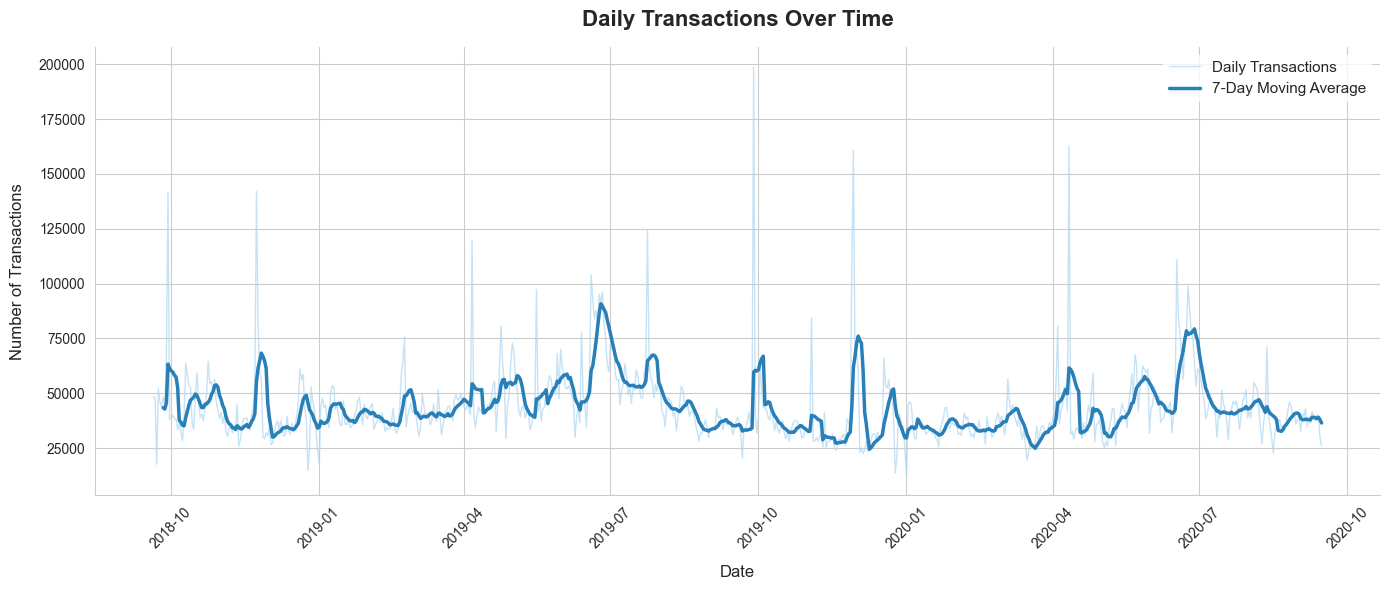

In [29]:
#============================================================================
#                        Daily purchases
#============================================================================

daily_total_sales = train.groupby('t_dat').size().reset_index(name='total_daily_sales')


moving_avg_7d = daily_total_sales['total_daily_sales'].rolling(window=7).mean()
moving_avg_7d.index=daily_total_sales['t_dat']

plt.figure(figsize=(14, 6))
sns.set_style("whitegrid")


plt.plot(
    daily_total_sales['t_dat'], 
    daily_total_sales['total_daily_sales'], 
    color='#aed6f1', 
    alpha=0.7, 
    linewidth=1, 
    label='Daily Transactions'
)


plt.plot(
    moving_avg_7d.index, 
    moving_avg_7d.values, 
    color='#2980b9', 
    linewidth=2.5, 
    label='7-Day Moving Average'
)

plt.title('Daily Transactions Over Time', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Date', fontsize=12, labelpad=10)
plt.ylabel('Number of Transactions', fontsize=12, labelpad=10)


plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)

plt.legend(frameon=True, facecolor='white', edgecolor='none', fontsize=11)

sns.despine()

plt.tight_layout()
plt.show()

* Daily purchases: some days show unusually high purchase volume, likely due to discounts. The popularity of products bought on those days may be artificially inflated.

* New Feature

In [30]:
# On Black Friday or extreme discount days, people buy products they wouldn't buy on regular days.
# Removing those days helps the model avoid learning this random noise

threshold = daily_total_sales['total_daily_sales'].quantile(0.95)
outlier_days = daily_total_sales[daily_total_sales['total_daily_sales'] > threshold]['t_dat']

print(f" Number of discount/anomalous days: {len(outlier_days)}")


train_organic = train[~train['t_dat'].isin(outlier_days)]

organic_popularity = train_organic.groupby('article_id').size().reset_index(name='organic_popularity')


articles = articles.merge(organic_popularity, on='article_id', how='left')
articles['organic_popularity'] = articles['organic_popularity'].fillna(0).astype(int)

 Number of discount/anomalous days: 37


In [31]:
#=============================================================================
#                          Customer Purchases
#=============================================================================
user_purchase_count = train.groupby('customer_id').size().reset_index(name='user_total_purchases')
user_purchase_count['user_total_purchases'].sort_values(ascending=False)


1007560    1895
958450     1427
390238     1356
881514     1355
1086478    1223
           ... 
1356674       1
1356668       1
1356663       1
1356662       1
1356661       1
Name: user_total_purchases, Length: 1356709, dtype: int64

In [32]:
user_purchase_count['user_total_purchases'].describe()

count    1.356709e+06
mean     2.325334e+01
std      3.903101e+01
min      1.000000e+00
25%      3.000000e+00
50%      9.000000e+00
75%      2.700000e+01
max      1.895000e+03
Name: user_total_purchases, dtype: float64

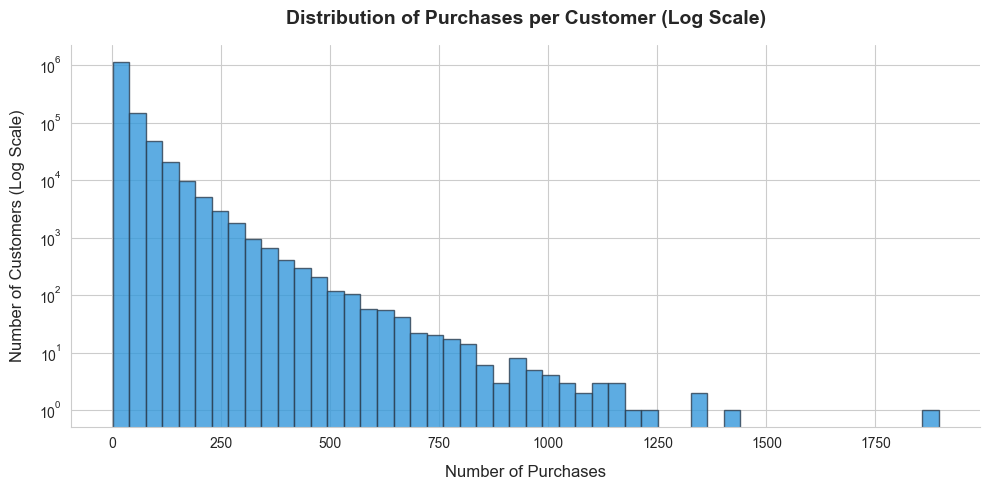

In [33]:
plt.figure(figsize=(10, 5))
sns.set_style("whitegrid")


plt.hist(
    user_purchase_count['user_total_purchases'], 
    bins=50, 
    log=True, 
    color='#3498db',      
    edgecolor='#2c3e50',  
    alpha=0.8
)


plt.title('Distribution of Purchases per Customer (Log Scale)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Number of Purchases', fontsize=12, labelpad=10)
plt.ylabel('Number of Customers (Log Scale)', fontsize=12, labelpad=10)


plt.xticks(fontsize=10)
plt.yticks(fontsize=10)


sns.despine()

plt.tight_layout()
plt.show()

In [34]:
max_row_index = user_purchase_count['user_total_purchases'].idxmax()

top_customer_id = user_purchase_count.loc[max_row_index, 'customer_id']

top_customer_rows = train[train['customer_id'] == top_customer_id]

print("Number of distinct purchase days:", top_customer_rows['t_dat'].nunique())
print("Number of distinct articles:", top_customer_rows['article_id'].nunique())

Number of distinct purchase days: 293
Number of distinct articles: 1346


In [35]:
top_20_rows = user_purchase_count.nlargest(20, 'user_total_purchases')
top_20_customers = top_20_rows['customer_id']

print(top_20_customers.values)

['be1981ab818cf4ef6765b2ecaea7a2cbf14ccd6e8a7ee985513d9e8e53c6d91b'
 'b4db5e5259234574edfff958e170fe3a5e13b6f146752ca066abca3c156acc71'
 '49beaacac0c7801c2ce2d189efe525fe80b5d37e46ed05b50a4cd88e34d0748f'
 'a65f77281a528bf5c1e9f270141d601d116e1df33bf9df512f495ee06647a9cc'
 'cd04ec2726dd58a8c753e0d6423e57716fd9ebcf2f14ed6012e7e5bea016b4d6'
 '55d15396193dfd45836af3a6269a079efea339e875eff42cc0c228b002548a9d'
 'c140410d72a41ee5e2e3ba3d7f5a860f337f1b5e41c27cf9bda5517c8774f8fa'
 '8df45859ccd71ef1e48e2ee9d1c65d5728c31c46ae957d659fa4e5c3af6cc076'
 '03d0011487606c37c1b1ed147fc72f285a50c05f00b9712e0fc3da400c864296'
 '6cc121e5cc202d2bf344ffe795002bdbf87178054bcda2e57161f0ef810a4b55'
 '3493c55a7fe252c84a9a03db338f5be7afbce1edbca12f3a908fac9b983692f2'
 'e34f8aa5e7c8c258523ea3e5f5f13168b6c21a9e8bffccd515dd5cef56126efb'
 '0bf4c6fd4e9d33f9bfb807bb78348cbf5c565846ff4006acf5c1b9aea77b0e54'
 'e6498c7514c61d3c24669f49753dc83fdff3ec1ba13902dd9184c959d8f0b249'
 '1320d4b3dd6481cde05bb80fb7ca37397f70470b9afb96

* Maximum of 1895 purchases (1346 distinct products, 293 days). Since this is far from the median, it's possible that multiple people are making purchases under the same account, which could interfere with CF or popularity calculations

In [36]:
# the value below which 99% of purchases fall

heavy_customer_threshold=user_purchase_count['user_total_purchases'].quantile(0.99)
top_customers_number=(user_purchase_count['user_total_purchases']>heavy_customer_threshold).sum()

print(top_customers_number/len(user_purchase_count)*100,'%')

0.9948338221387194 %


In [37]:
# =============================================================================
#                   Heavy Customers Share Analysis
# =============================================================================

heavy_users_total_purchases = user_purchase_count[
    user_purchase_count['user_total_purchases'] > heavy_customer_threshold
]['user_total_purchases'].sum()

all_users_total_purchases = user_purchase_count['user_total_purchases'].sum()

heavy_customers_purchase_share = (heavy_users_total_purchases / all_users_total_purchases) * 100

print(f"Heavy customers purchase share: {heavy_customers_purchase_share:.2f}%")

Heavy customers purchase share: 11.57%


* Removing these customers would lose a lot of data, and they're also likely to make purchases in the validation week. They skew popularity and CF toward themselves, since they make a large number of purchases

* New Feature

In [38]:
# Add each customer_id's total number of purchases to the data

customers = customers.merge(user_purchase_count, on='customer_id', how='left')

customers['user_total_purchases'] = customers['user_total_purchases'].fillna(0).astype(int)

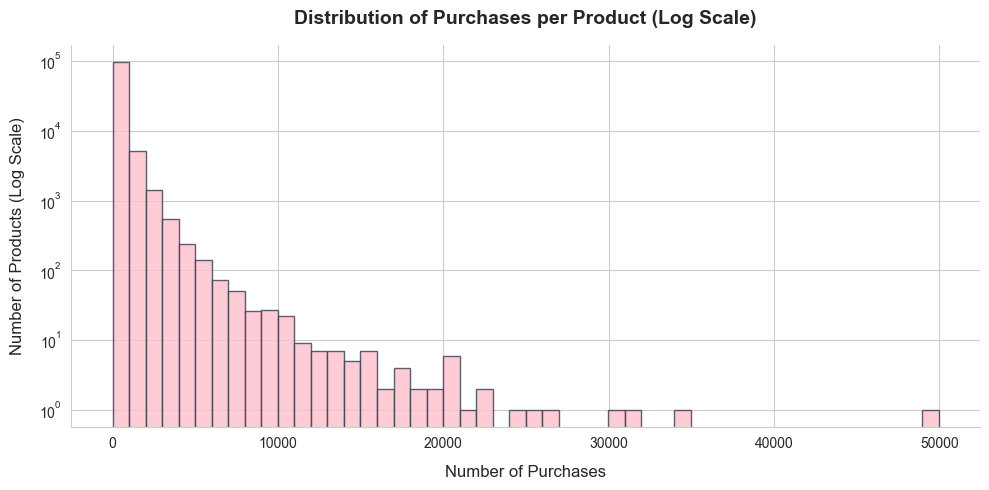

In [39]:
#==================================================================================
#             Number of purchases per article in train
#==================================================================================
product_counts = train.groupby('article_id').size().reset_index(name='item_total_purchases')

plt.figure(figsize=(10, 5))
sns.set_style("whitegrid")

plt.hist(
    product_counts['item_total_purchases'],        
    bins=50,
    log=True,
    color='pink',
    edgecolor='#2c3e50',
    alpha=0.8
)

plt.title('Distribution of Purchases per Product (Log Scale)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Number of Purchases', fontsize=12, labelpad=10)
plt.ylabel('Number of Products (Log Scale)', fontsize=12, labelpad=10)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

sns.despine()
plt.tight_layout()
plt.show()

In [40]:
# =============================================================================
#                   Top 10 Most Purchased Products
# =============================================================================

top_10_products = product_counts.nlargest(10, 'item_total_purchases')
top_10_article_ids = top_10_products['article_id']

print("Top 10 Article:")
top_10_products

Top 10 Article:


,article_id,item_total_purchases
53792,706016001,49958
53793,706016002,34802
1707,372860001,31482
24782,610776002,30003
70054,759871002,26309
3700,464297007,24989
1708,372860002,24222
24781,610776001,22335
2229,399223001,22204
58380,720125001,21005


In [41]:
# =============================================================================
#                   Top 1% Heavy Products & Sales Share Analysis
# =============================================================================

heavy_product_threshold = product_counts['item_total_purchases'].quantile(0.99)
heavy_products_count = (product_counts['item_total_purchases'] > heavy_product_threshold).sum()

heavy_products_catalog_share = (heavy_products_count / len(product_counts)) * 100


heavy_products_sales_sum = product_counts[product_counts['item_total_purchases'] > heavy_product_threshold]['item_total_purchases'].sum()
total_sales_sum = product_counts['item_total_purchases'].sum()

top_article_sales_share = (heavy_products_sales_sum / total_sales_sum) * 100

print(f"Heavy product threshold: {heavy_product_threshold} purchases")
print(f"Top products count share: {heavy_products_catalog_share:.2f}% of catalog")
print(f"Top products sales share: {top_article_sales_share:.2f}% of total purchases")

Heavy product threshold: 3186.4199999999837 purchases
Top products count share: 1.00% of catalog
Top products sales share: 18.60% of total purchases


* Although these products make up ~1% of the total, they account for 18.6% of purchases

* New Feature

In [42]:
# Add each article_id's total sales count to the data

articles = articles.merge(product_counts, on='article_id', how='left')

articles['item_total_purchases'] = articles['item_total_purchases'].fillna(0).astype(int)

In [43]:
#=================================================================================
#        Customers who made repeat purchases
#=================================================================================

repeat_counts = train.groupby(['customer_id', 'article_id']).size()

repeat_counts.describe()

count    2.710115e+07
mean     1.164084e+00
std      5.722045e-01
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      5.700000e+02
dtype: float64

In [44]:
# How many (customer, article) pairs were bought more than once

repeated_pairs = (repeat_counts > 1).sum()
print(repeated_pairs,' \n', repeated_pairs / len(repeat_counts) * 100, '%')

3488256  
 12.871248110965631 %


In [45]:
# What share of ALL purchases come from pairs that were bought more than once

repeat_share = repeat_counts[repeat_counts > 1].sum() / repeat_counts.sum() * 100
print(repeat_share, '%')

25.15252228405003 %


* 12% of pairs account for 25% of purchases. This means repeat purchases are a significant pattern, not a rare occurrence.

In [46]:
# the 12 most purchased products by volume
top_by_purchases=train.groupby('article_id').size().nlargest(12)
# the 12 most popular by number of unique customers
top_by_customers=train.groupby('article_id')['customer_id'].nunique().nlargest(12)

In [47]:
top_by_purchases

article_id
706016001    49958
706016002    34802
372860001    31482
610776002    30003
759871002    26309
464297007    24989
372860002    24222
610776001    22335
399223001    22204
720125001    21005
706016003    20957
156231001    20884
dtype: int64

In [48]:
top_by_customers

article_id
706016001    32068
372860001    25381
706016002    25320
610776002    22444
759871002    21597
372860002    19866
464297007    18535
720125001    17557
673396002    17016
610776001    16770
673677002    16384
706016003    16042
Name: customer_id, dtype: int64

In [49]:
common_articles=top_by_purchases.index.isin(top_by_customers.index)
print(common_articles.sum())

10


* Popularity by purchases vs by unique customers. The top 12 almost coincide; the difference comes from a few heavy buyers.

* New Feature

In [50]:
# Number of distinct customers who bought the product
item_unique_buyers = train.groupby('article_id')['customer_id'].nunique().reset_index(name='item_unique_buyers')

articles = articles.merge(item_unique_buyers, on='article_id', how='left')
articles['item_unique_buyers'] = articles['item_unique_buyers'].fillna(0).astype(int)

* New Feature

In [51]:
#=========================================================================
#                  Total amount spent by each customer
#=========================================================================
user_spend = train.groupby('customer_id')['price'].sum().reset_index(name='user_total_spend')

user_spend.sort_values(by='user_total_spend',ascending=False)

,customer_id,user_total_spend
1007560,be1981ab818cf4ef6765b2ecaea7a2cbf14ccd6e8a7ee9...,57.676407
881514,a65f77281a528bf5c1e9f270141d601d116e1df33bf9df...,50.628067
20083,03d0011487606c37c1b1ed147fc72f285a50c05f00b971...,49.933289
958450,b4db5e5259234574edfff958e170fe3a5e13b6f146752c...,46.940205
133017,191071b0e1f2e94a557f1a0b4cea3de55faf1581b1f464...,46.301086
...,...,...
863224,a2efffd45ccdc46ea647c1e18037200934b7c250a5f211...,0.000847
757664,8f06cf200f1fbc9c8a91ce6783a18ccae68463a46edabd...,0.000847
965835,b6345f8bf3fdb4a9833a812e11aaebfd6e2f256e8834d4...,0.000847
989432,bab2bbc49b68666736892e7501f04fddbdbe31b4c4d382...,0.000847


* Having this column lets us get a sense of whether the customer bought expensive items or not

In [52]:

customers = customers.merge(user_spend, on='customer_id', how='left')

customers['user_total_spend'] = customers['user_total_spend'].fillna(0)

* New Feature

* Whether the customer made more purchases online or in-store

In [53]:
preferred_channel = (train.groupby('customer_id')['sales_channel_id']
                .agg(lambda x: 1 if (x == 2).sum() > (x == 1).sum() else 0)
                .reset_index(name='is_preferred_online'))

customers = customers.merge(preferred_channel, on='customer_id', how='left')
customers['is_preferred_online'] = customers['is_preferred_online'].fillna(0).astype(int)

In [54]:
preferred_channel.head()

,customer_id,is_preferred_online
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,1
1,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,1
2,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,1
3,00005ca1c9ed5f5146b52ac8639a40ca9d57aeff4d1bd2...,1
4,00006413d8573cd20ed7128e53b7b13819fe5cfc2d801f...,1


* New Feature

In [55]:
# For each product, note the season during which it sold the most (1: Spring, 2: Summer, 3: Autumn, 4: Winter)

def get_season(month):
    if month in [3, 4, 5]:
        return 1
    elif month in [6, 7, 8]:
        return 2
    elif month in [9, 10, 11]:
        return 3
    else:
        return 4


train['month'] = pd.to_datetime(train['t_dat']).dt.month
train['season'] = train['month'].apply(get_season)


item_season_sales = train.groupby(['article_id', 'season']).size().reset_index(name='sales_count')
item_peak_season = item_season_sales.sort_values(['article_id', 'sales_count'], ascending=[True, False])
item_peak_season = item_peak_season.drop_duplicates(subset=['article_id'])[['article_id', 'season']]
item_peak_season.rename(columns={'season': 'item_peak_season'}, inplace=True)


articles = articles.merge(item_peak_season, on='article_id', how='left')
articles['item_peak_season'] = articles['item_peak_season'].fillna(-1).astype(int)


C:\Users\user\AppData\Local\Temp\ipykernel_7208\2740920063.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['month'] = pd.to_datetime(train['t_dat']).dt.month
C:\Users\user\AppData\Local\Temp\ipykernel_7208\2740920063.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['season'] = train['month'].apply(get_season)


* Prevents recommending products from the "wrong season"

## EDA: Articles

In [56]:
articles.head()

,article_id,product_code,prod_name,product_type_no,product_type_name,product_group_name,graphical_appearance_no,graphical_appearance_name,colour_group_code,colour_group_name,...,index_group_name,section_no,section_name,garment_group_no,garment_group_name,detail_desc,organic_popularity,item_total_purchases,item_unique_buyers,item_peak_season
0,108775015,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,9,Black,...,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.,9852,10841,6885,4
1,108775044,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,10,White,...,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.,6469,7247,5283,1
2,108775051,108775,Strap top (1),253,Vest top,Garment Upper body,1010017,Stripe,11,Off White,...,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.,203,215,168,3
3,110065001,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,9,Black,...,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulde...",921,1044,945,3
4,110065002,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,10,White,...,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulde...",513,539,460,4


In [57]:
print(articles.shape)
print('\n',articles.columns.to_list())
print('\n',articles.dtypes)

(105542, 29)

 ['article_id', 'product_code', 'prod_name', 'product_type_no', 'product_type_name', 'product_group_name', 'graphical_appearance_no', 'graphical_appearance_name', 'colour_group_code', 'colour_group_name', 'perceived_colour_value_id', 'perceived_colour_value_name', 'perceived_colour_master_id', 'perceived_colour_master_name', 'department_no', 'department_name', 'index_code', 'index_name', 'index_group_no', 'index_group_name', 'section_no', 'section_name', 'garment_group_no', 'garment_group_name', 'detail_desc', 'organic_popularity', 'item_total_purchases', 'item_unique_buyers', 'item_peak_season']

 article_id                       int64
product_code                     int64
prod_name                       object
product_type_no                  int64
product_type_name               object
product_group_name              object
graphical_appearance_no          int64
graphical_appearance_name       object
colour_group_code                int64
colour_group_name            

In [58]:
articles.nunique()

article_id                      105542
product_code                     47224
prod_name                        45875
product_type_no                    132
product_type_name                  131
product_group_name                  19
graphical_appearance_no             30
graphical_appearance_name           30
colour_group_code                   50
colour_group_name                   50
perceived_colour_value_id            8
perceived_colour_value_name          8
perceived_colour_master_id          20
perceived_colour_master_name        20
department_no                      299
department_name                    250
index_code                          10
index_name                          10
index_group_no                       5
index_group_name                     5
section_no                          57
section_name                        56
garment_group_no                    21
garment_group_name                  21
detail_desc                      43404
organic_popularity       

In [59]:
articles.isna().sum()

article_id                        0
product_code                      0
prod_name                         0
product_type_no                   0
product_type_name                 0
product_group_name                0
graphical_appearance_no           0
graphical_appearance_name         0
colour_group_code                 0
colour_group_name                 0
perceived_colour_value_id         0
perceived_colour_value_name       0
perceived_colour_master_id        0
perceived_colour_master_name      0
department_no                     0
department_name                   0
index_code                        0
index_name                        0
index_group_no                    0
index_group_name                  0
section_no                        0
section_name                      0
garment_group_no                  0
garment_group_name                0
detail_desc                     416
organic_popularity                0
item_total_purchases              0
item_unique_buyers          

In [60]:
articles.describe()

,article_id,product_code,product_type_no,graphical_appearance_no,colour_group_code,perceived_colour_value_id,perceived_colour_master_id,department_no,index_group_no,section_no,garment_group_no,organic_popularity,item_total_purchases,item_unique_buyers,item_peak_season
count,1.055420e+05,105542.000000,105542.000000,1.055420e+05,105542.000000,105542.000000,105542.000000,105542.000000,105542.000000,105542.000000,105542.000000,105542.000000,105542.000000,105542.000000,105542.000000
mean,6.984246e+08,698424.563378,234.861875,1.009515e+06,32.233822,3.206183,7.807972,4532.777833,3.171534,42.664219,1010.438290,264.764416,298.914300,256.780694,2.502227
std,1.284624e+08,128462.384432,75.049308,2.241359e+04,28.086154,1.563839,5.376727,2712.692011,4.353234,23.260105,6.731023,697.802992,783.982937,632.293835,1.100406
min,1.087750e+08,108775.000000,-1.000000,-1.000000e+00,-1.000000,-1.000000,-1.000000,1201.000000,1.000000,2.000000,1001.000000,0.000000,0.000000,0.000000,-1.000000
25%,6.169925e+08,616992.500000,252.000000,1.010008e+06,9.000000,2.000000,4.000000,1676.000000,1.000000,20.000000,1005.000000,11.000000,12.000000,11.000000,2.000000
50%,7.022130e+08,702213.000000,259.000000,1.010016e+06,14.000000,4.000000,5.000000,4222.000000,2.000000,46.000000,1009.000000,56.000000,61.000000,55.000000,3.000000
75%,7.967030e+08,796703.000000,272.000000,1.010016e+06,52.000000,4.000000,11.000000,7389.000000,4.000000,61.000000,1017.000000,249.000000,279.000000,244.000000,3.000000
max,9.594610e+08,959461.000000,762.000000,1.010029e+06,93.000000,7.000000,20.000000,9989.000000,26.000000,97.000000,1025.000000,45331.000000,49958.000000,32068.000000,4.000000


In [61]:
# product code -- product name
articles['product_code'].value_counts().head()

product_code
783707    75
684021    70
699923    52
699755    49
685604    46
Name: count, dtype: int64

In [62]:
code_name=articles.groupby('product_code')['prod_name'].nunique().sort_values(ascending=False)
print((code_name>1).sum())
code_name

2176


product_code
624543    5
573605    5
589521    5
337777    5
624443    5
         ..
953450    1
953763    1
956217    1
957375    1
948758    1
Name: prod_name, Length: 47224, dtype: int64

* About 95% of the product_codes have exactly one name, while only ~5% have more than one. Thus, prod_name mostly mirrors product_code, but not completely.

In [63]:
# product_type_no -- product_type_name
(articles[['product_type_no','product_type_name']].drop_duplicates())['product_type_name'].value_counts()

product_type_name
Umbrella                  2
Bra                       1
Vest top                  1
Underwear Tights          1
Socks                     1
                         ..
Dog wear                  1
Eyeglasses                1
Wireless earphone case    1
Stain remover spray       1
Clothing mist             1
Name: count, Length: 131, dtype: int64

In [64]:
articles[articles['product_type_name']=='Umbrella']['product_type_no'].unique()

array([532,  83])

In [65]:
# Check how many articles have each of the two product_type_no codes that share the name 'Umbrella'
print(len(articles[articles['product_type_no'] == 532]))  # articles with code 532
print(len(articles[articles['product_type_no'] == 83]))   # articles with code 83

3
26


* Keep only one of the product_type_no and product_type_name columns.

In [66]:
print(len(articles[['graphical_appearance_no','graphical_appearance_name']].drop_duplicates()))
# They provide the same information
articles[articles['graphical_appearance_no']==-1]['graphical_appearance_name'].unique()

# The -1 code in graphical_appearance stands for 'Unknown' 

30


array(['Unknown'], dtype=object)

In [67]:
print(articles[['colour_group_code','colour_group_name']].drop_duplicates().shape)

articles[articles['colour_group_code']==-1]['colour_group_name'].unique()

(50, 2)


array(['Unknown'], dtype=object)

In [68]:
print(articles[['perceived_colour_value_id','perceived_colour_value_name']].drop_duplicates().shape)
print(articles[['perceived_colour_master_id', 'perceived_colour_master_name']].drop_duplicates().shape)
print(articles[['department_no', 'department_name']].drop_duplicates().shape)

(8, 2)
(20, 2)
(299, 2)


* product_group_name can be one-hot encoded.

* The graphical_appearance_no and graphical_appearance_name pair corresponds 1-to-1 (provides the same information); keep only one for the model.

* Code -1 in graphical_appearance means "Unknown". Treat it as a regular category.

* colour_group_code and colour_group_name are identical (provide the same information).

### Category-based EDA։


In [69]:
# group popularity
df_trans_articles=train.merge(
    articles[['article_id','product_group_name']],
    on='article_id',
    how='left'
)

group_counts = df_trans_articles.groupby('product_group_name').size().sort_values(ascending=False)
group_counts


product_group_name
Garment Upper body       12437485
Garment Lower body        6991579
Garment Full body         3532809
Swimwear                  2576236
Underwear                 2547655
Accessories               1587280
Shoes                      741371
Socks & Tights             679805
Nightwear                  344968
Unknown                     93380
Bags                         7177
Items                        5104
Cosmetic                     1495
Underwear/nightwear           558
Furniture                     533
Garment and Shoe care         278
Stationery                    224
Interior textile               74
Fun                             2
dtype: int64

C:\Users\user\AppData\Local\Temp\ipykernel_7208\3384570708.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=group_counts.values, y=group_counts.index, palette='viridis')


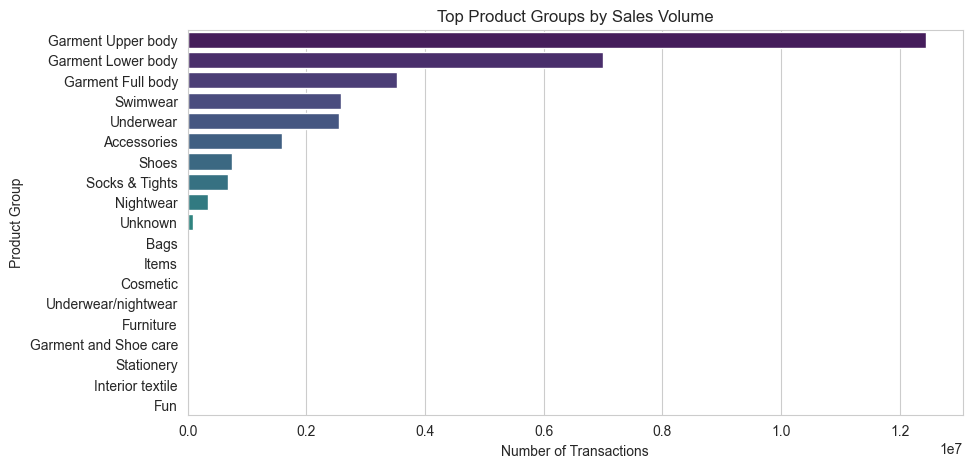

In [70]:
plt.figure(figsize=(10, 5))
sns.barplot(x=group_counts.values, y=group_counts.index, palette='viridis')
plt.title('Top Product Groups by Sales Volume')
plt.xlabel('Number of Transactions')
plt.ylabel('Product Group')
plt.show()

* Garment Upper and Lower body account for the vast majority of total sales.

* Bags, Items, Cosmetics, Furniture, Stationery, Interior textile, and Fun are almost invisible in the graph.

This imbalance means that popularity-based baselines (top-12) will recommend Garment Upper/Lower body items almost exclusively, as they are bought most frequently overall.

C:\Users\user\AppData\Local\Temp\ipykernel_7208\673282306.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=color_counts.values, y=color_counts.index, palette='viridis')


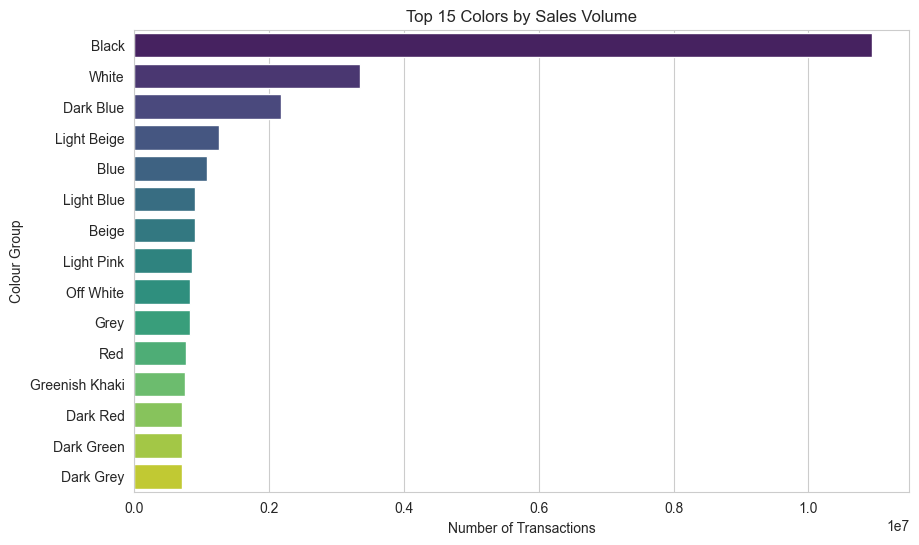

In [71]:
# Overall color popularity (top 15 only)
color_counts = train.merge(
    articles[['article_id', 'colour_group_name']],
    on='article_id',
    how='left'
).groupby('colour_group_name').size().sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=color_counts.values, y=color_counts.index, palette='viridis')
plt.title('Top 15 Colors by Sales Volume')
plt.xlabel('Number of Transactions')
plt.ylabel('Colour Group')
plt.show()

* New Feature

In [72]:
# Extract the customer's favorite color as a feature.
customer_color = train.merge(
    articles[['article_id', 'colour_group_code']],
    on='article_id',
    how='left'
)

favorite_color = (
    customer_color.groupby(['customer_id', 'colour_group_code'])
    .size()
    .reset_index(name='count')
    .sort_values(['customer_id', 'count'], ascending=[True, False])
    .drop_duplicates('customer_id')
    .set_index('customer_id')['colour_group_code']
)

customers = customers.merge(
    favorite_color.rename('favorite_color_code'),
    on='customer_id',
    how='left'
)

customers['favorite_color_code'] = customers['favorite_color_code'].fillna(-1)

C:\Users\user\AppData\Local\Temp\ipykernel_7208\2402692774.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_colors.values, y=top_colors.index, palette='viridis')


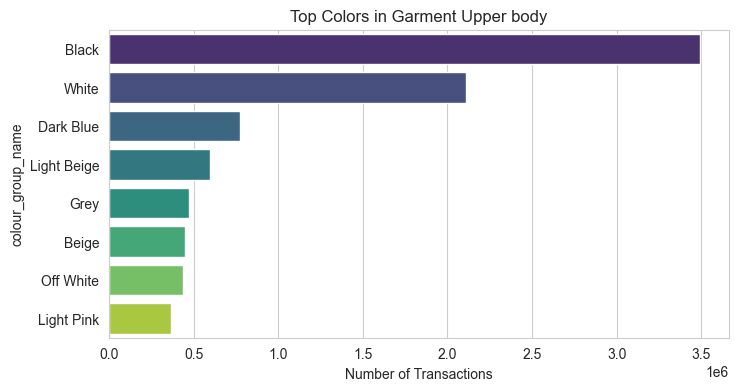

C:\Users\user\AppData\Local\Temp\ipykernel_7208\2402692774.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_colors.values, y=top_colors.index, palette='viridis')


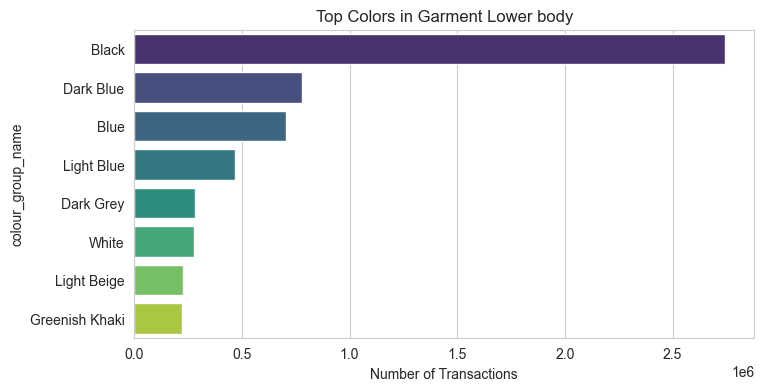

C:\Users\user\AppData\Local\Temp\ipykernel_7208\2402692774.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_colors.values, y=top_colors.index, palette='viridis')


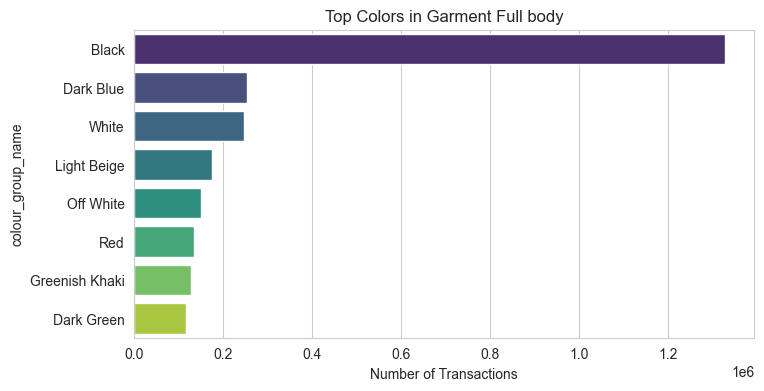

In [73]:
# Color breakdown within top product groups
df_full = train.merge(
    articles[['article_id', 'product_group_name', 'colour_group_name']],
    on='article_id',
    how='left'
)

top_groups = df_full['product_group_name'].value_counts().nlargest(3).index

for group in top_groups:
    subset = df_full[df_full['product_group_name'] == group]
    top_colors = subset['colour_group_name'].value_counts().nlargest(8)
    
    plt.figure(figsize=(8, 4))
    sns.barplot(x=top_colors.values, y=top_colors.index, palette='viridis')
    plt.title(f'Top Colors in {group}')
    plt.xlabel('Number of Transactions')
    plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_7208\3694721598.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_colors.values, y=top_colors.index, palette='viridis')


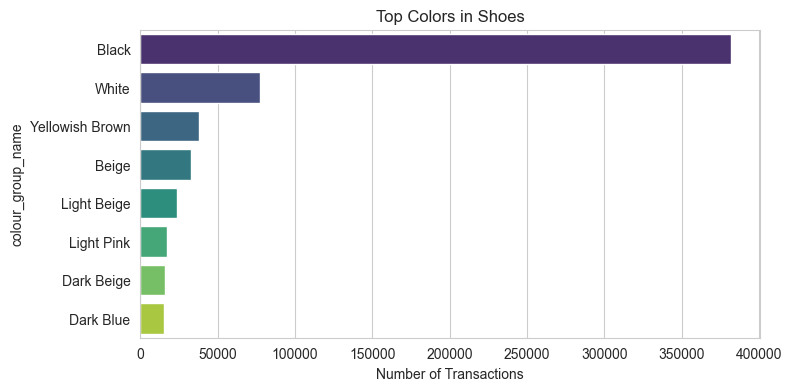

C:\Users\user\AppData\Local\Temp\ipykernel_7208\3694721598.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_colors.values, y=top_colors.index, palette='viridis')


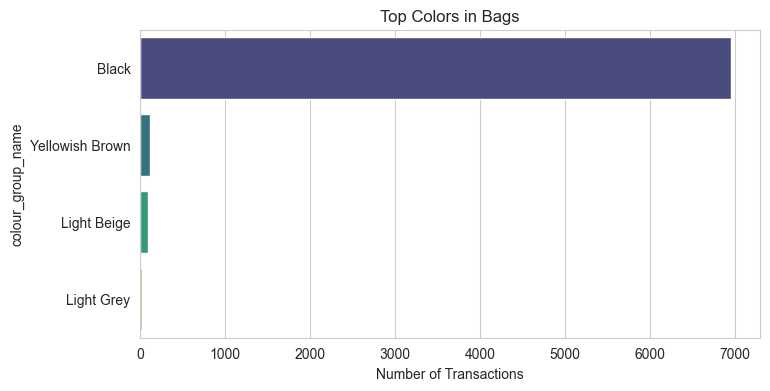

In [74]:
for group in ['Shoes','Bags']:
    subset = df_full[df_full['product_group_name'] == group]
    top_colors = subset['colour_group_name'].value_counts().nlargest(8)
    
    plt.figure(figsize=(8, 4))
    sns.barplot(x=top_colors.values, y=top_colors.index, palette='viridis')
    plt.title(f'Top Colors in {group}')
    plt.xlabel('Number of Transactions')
    plt.show()

* Since almost the same colors dominate across all categories, it can be concluded that color is a secondary feature

* New Feature

In [75]:
# Performing One-Hot Encoding for product_group_name
group_encoded = pd.get_dummies(
    articles['product_group_name'], 
    prefix='group', 
    dtype=int
)


articles = pd.concat([articles, group_encoded], axis=1)

articles.drop(columns=['product_group_name'], inplace=True)

In [76]:
(articles==-1).sum()

# The count of 'Unknown' values is small. 
# Therefore, these -1s are not an issue for the model, they simply represent an 'Unknown' category.

article_id                         0
product_code                       0
prod_name                          0
product_type_no                  121
product_type_name                  0
graphical_appearance_no           52
graphical_appearance_name          0
colour_group_code                 28
colour_group_name                  0
perceived_colour_value_id         28
perceived_colour_value_name        0
perceived_colour_master_id       685
perceived_colour_master_name       0
department_no                      0
department_name                    0
index_code                         0
index_name                         0
index_group_no                     0
index_group_name                   0
section_no                         0
section_name                       0
garment_group_no                   0
garment_group_name                 0
detail_desc                        0
organic_popularity                 0
item_total_purchases               0
item_unique_buyers                 0
i

* Do not drop the 416 NaN rows in detail_desc, if text is used, fill them with empty strings

### Drop column

In [77]:
# =============================================================================
#          Dropping Redundant Text Columns from Articles Dataset
# =============================================================================

text_columns_to_drop = [
    'prod_name',
    'product_type_name',
    'graphical_appearance_name',
    'colour_group_name',
    'perceived_colour_value_name',
    'perceived_colour_master_name',
    'department_name',
    'index_name',
    'index_group_name',
    'section_name',
    'garment_group_name'
]


for col in text_columns_to_drop:
    articles.drop(columns=[col], inplace=True, errors='ignore')



In [78]:
transactions.to_parquet('transactions_processed.parquet', index=False)
customers.to_parquet('customers_processed.parquet', index=False)
articles.to_parquet('articles_processed.parquet', index=False)
